<a href="https://colab.research.google.com/github/oluaptom-dev/DBN/blob/main/DSTNM_300426_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Differential Binary Noise Modulation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, stats, special
from scipy.special import erfc

In [ ]:
# A segundo ideia agora é retirar o alfabeto e deixar ruido
#  alphabet -> noise_alphabet
# 1) A mudança da ancora (matriz identidade)
# 2) Alfabeto deve ser estatistico (não deve pertencer a um alfabeto fixo).


# Vamos gerar ao novo :    Quaternion Rotated Noise Codebook    C={Gi​Z}i=18​
# ==========================
# MATRIZES GERADORAS  = origem dos quaternios - ficará algo ponto de partida e talvez haja comparação
# ==========================
I = np.eye(2, dtype=complex)

g1 = np.array([[1j, 0],
               [0, -1j]], dtype=complex)

g2 = np.array([[0, -1],
               [1,  0]], dtype=complex)

g1g2 = g1 @ g2

# Alfabeto quaternionico
alphabet = [
    I, -I,
    g1, -g1,
    g2, -g2,
    g1g2, -g1g2
]

# ==========================
# FUNÇÃO DE NORMALIZAÇÃO
# ==========================
def normalize_fro(M):                                # só normaliza energia, não torna unitário.
    return M / np.linalg.norm(M, 'fro')

# ==========================
# GERAR BASE NOISE MATRIX
# ==========================

def generate_base_noise():
    A = np.random.randn(2,2) + 1j*np.random.randn(2,2) # gera novo ruido "BASE" = NORMAL (0,1)
    Q, R = np.linalg.qr(A)                             # com : Q^HQ=I  então Z^HZ= (1/2)​I    ok
    return (1/np.sqrt(2))*Q                            # normaliza = potencia = 1. Q tem potencia igual n (caso=2). Mas ao multiplicar passar a ter potencia = 1 similar a X_prev = alfa*I
    # Como $Q$ é uma matriz unitária (derivada da decomposição QR), o seu determinante é sempre um número complexo com módulo igual a 1.
    # $$|\det(Q)| = 1$$
    # multiplicamos a matriz por um escalar $c$, o determinante é multiplicado por $c^n$  Logo fica: \det(Z) = \frac{1}{2} \det(Q)  = METADE DE Q

# ==========================
# GERAR NOISE CODEBOOK                                  # gerar o ALFABETO = CODEBOOK
# ==========================                            # usa a BASE para cada codigo
def generate_noise_codebook():
    Z = generate_base_noise()   # base e normalizada

    codebook = []

    for G in alphabet:          # para cada item do alfabeto cria un Nk
        Nk = G @ Z              # Nk = G @ Z
        Nk = normalize_fro(Nk)  # nao é mais necessario pois agora usa função com Q,R
        codebook.append(Nk)

    return codebook

In [ ]:
def run_simulation_dstnm(snr_db_range, num_blocks):

    ser_diff = []
    ser_coh = []
    ber_diff = []
    ber_coh = []

    for i, snr_db in enumerate(snr_db_range):

        print(f"[{i+1}/{len(snr_db_range)}] SNR = {snr_db} dB")

        rho = 10**(snr_db / 10)      # ρ_t = ρ/2 (SNR/antena)   (rho é a SNR!)
        sigma_w2 = 1.0 / (2*rho)    #  variância do ruído como inversamente proporcional ao SNR (ρ). Duvida acho que o 2 aqui é para dividir por t antenas.
        ########### TESTE101 NA LINHA ABAIXO
        #sigma_w2 = 0     # teste é como se SNR fosse infinita -  Leva o ruido a ser insignificante


        errors_diff = 0
        errors_coh = 0
        errors_diff_BER = 0
        errors_coh_BER = 0
        valid_blocks = 0


        # TESTE PARA DEPURAR   = use o seed no parentese ou não
        seed = 42 # Define a semente (pode ser qualquer número inteiro ou ussar aleatorio definir isso depis)
        rng = np.random.default_rng()
        # Agora use rng.standard_normal ou rng.normal em vez de np.random.randn
        H = (rng.standard_normal((1, 2)) + 1j * rng.standard_normal((1, 2))) / np.sqrt(2)  # sqrt(2) é normatizar potencia.

        ########### Alterando a matriz inicial - unitaria e normalizada para MATRIZ DE RUIDO unitaria e normalizada  = DSTNM
        Q, R = np.linalg.qr((np.random.randn(2, 2) + 1j * np.random.randn(2, 2)))
        X_prev = (1/np.sqrt(2)) * Q

        #################### alterando de alfabeto para codebook
        noise_codebook = generate_noise_codebook()   # inicio de um FRAME escolha de um novo RUIDO BASE --> NOVO CODEBOOK
        ####################
        # Primeira observação (referência)
        noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) #normaliza a variancia total (real+imag)
        Y_prev = H @ X_prev + noise    # Canal Rayleigh + ruido AWGN

        skip_next = False  # controle do overhead extra
        for k in range(num_blocks):

            # ==========================
            # Troca de canal (block fading)
            # ==========================
            # Vai fazer esse proximo if a cada 100; 200; 300...  ou seja na troca a CADA 100 blocos ( L =100 foi definido) !!!!
            if k % 100 == 0 and k > 0:       # (resto da divisão por 100)  E  (verifica se é ZERO )Logo é multiplo de 100!
                H = (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) / np.sqrt(2)

                # reinicializa referência
                ########### Alterando a matriz inicial - unitaria e normalizada para MATRIZ DE RUIDO unitaria e normalizada  = DSTNM
                Q, R = np.linalg.qr((np.random.randn(2, 2) + 1j * np.random.randn(2, 2)))
                X_prev = (1/np.sqrt(2)) * Q
                noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
                Y_prev = H @ X_prev + noise

                skip_next = True
                continue    # pula o resto do codigo e vai proximo contagem! Ex tava em 100. Vai pra 101.

            # ==========================
            # bloco após reset (não detecta) Sera sempro o 101; 201; 301 ...
            # ==========================
            if skip_next:
                idx = np.random.randint(0, 8)   # INICO de um novo FRAME
                ####### Mudança de alfabeto fixo para codebook
                noise_codebook = generate_noise_codebook()   # inicio de um FRAME escolha de um novo RUIDO BASE --> NOVO CODEBOOK
                Nk_true = noise_codebook[idx]      # Nk veio de    --> Nk = G @ Z
                #######

                # nao usar X_curr =  X_prev @ G_true  # multiplicar pela direita   Y_k = (H X_k-1)G  = Y_k @ G = correto
                X_curr =   X_prev @ Nk_true      # Eq 13 ok para DSTM .
                X_curr = X_curr / np.linalg.norm(X_curr,'fro')        # Isso pode alterar estrutura diferencial ideal.???


                noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
                Y_curr = H @ X_curr + noise

                X_prev = X_curr
                Y_prev = Y_curr

                skip_next = False
                continue  # pula o resto do codigo e vai proximo contagem!
                # Veja que o valid_block só é contabilizado de 102 até 199
                #
            # ==========================
            # símbolo normal
            # ==========================
            idx = np.random.randint(0, 8)
            Nk_true = noise_codebook[idx]
            #######

            X_curr =   X_prev @ Nk_true
            X_curr = X_curr / np.linalg.norm(X_curr,'fro')     # Isso pode alterar estrutura diferencial ideal.???

            # Canal
            noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
            Y_curr = H @ X_curr + noise

            # ==========================
            # DETECTOR DIFERENCIAL (Eq. 16)
            # ==========================
            M = Y_curr.conj().T @ Y_prev  # (2x2)


            metrics_diff = []
            for N in noise_codebook:     # vai testar cada uma das matrizes
                val = np.real(np.trace(N @ M))
                metrics_diff.append(float(val))

            idx_hat_diff = np.argmax(metrics_diff)

            # ==========================
            # DETECTOR COERENTE
            # ==========================
            metrics_coh = []
            for N in noise_codebook:
                X_test =  X_prev @ N
                diff_vec = Y_curr - H @ X_test
                val = -np.sum(np.abs(diff_vec)**2)
                metrics_coh.append(float(val))

            idx_hat_coh = np.argmax(metrics_coh)

            # ==========================
            # contagem de erros de simbolos
            # ==========================
            if idx_hat_diff != idx:
                errors_diff += 1

            if idx_hat_coh != idx:
                errors_coh += 1

            # Para simbolos = SER
            valid_blocks += 1              # Cada simbolo valido  (0 ate 99 = 100 simbolos, depois perde 100 e 101 e conta 102 até 199 = 98). Logo são 100+99+98+98+...
            # ==========================
            # contagem de erros de bit
            # ==========================
            bit_errors_diff = bin(idx_hat_diff ^ idx).count('1')  #considerando 3 bits por símbolo
            errors_diff_BER += bit_errors_diff

            bit_errors_coh = bin(idx_hat_coh ^ idx).count('1')  #considerando 3 bits por símbolo
            errors_coh_BER += bit_errors_coh

            # Para bits = BER
            total_bits = 3 * valid_blocks  # Cada símbolo válido carrega 3 bits           Cada simbolo tem 3 bits


            X_prev = X_curr
            Y_prev = Y_curr



        ser_diff.append(errors_diff / valid_blocks)
        ser_coh.append(errors_coh / valid_blocks)

        ber_diff.append(errors_diff_BER / total_bits)
        ber_coh.append(errors_coh_BER / total_bits)

    print("✅ Simulação concluída!")

    return ser_diff, ser_coh, ber_diff, ber_coh

[1/7] SNR = 5.0 dB
[2/7] SNR = 7.5 dB
[3/7] SNR = 10.0 dB
[4/7] SNR = 12.5 dB
[5/7] SNR = 15.0 dB
[6/7] SNR = 17.5 dB
[7/7] SNR = 20.0 dB
✅ Simulação concluída!


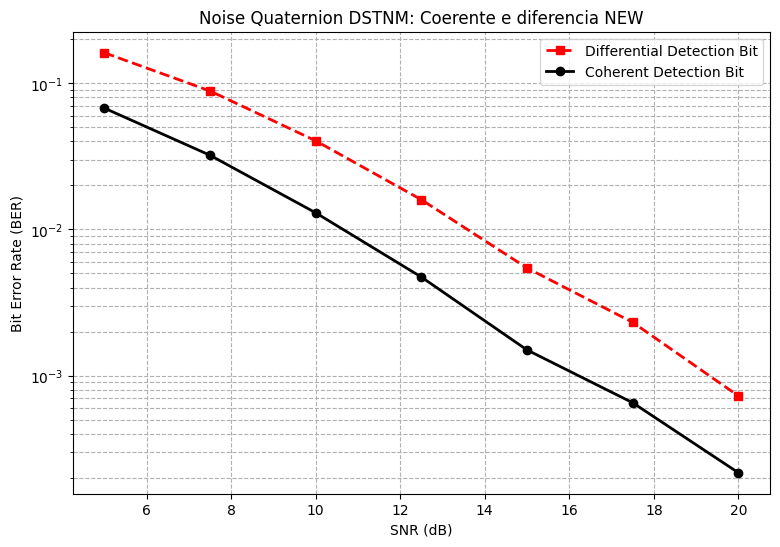

In [ ]:
# --- Execução e Plotagem  DSTNM  ---

snr_range = np.arange(5, 21, 2.5)

ser_diff, ser_coh, ber_diff, ber_coh = run_simulation_dstnm(snr_range, num_blocks=1000000) # 10k=ruim / 100k=ok / 500k=bom  / 1M+=artigo
                                                                                          # 16s          2mi                    27min

plt.figure(figsize=(9,6))

#plt.semilogy(snr_range, ser_diff, 'r--s', linewidth=2, markersize=6, label='Differential Detection Simbolo')
#plt.semilogy(snr_range, ser_coh, 'b--o', linewidth=2, markersize=6, label='Coherent Detection Simbolo')
plt.semilogy(snr_range, ber_diff, 'r--s', linewidth=2, markersize=6, label='Differential Detection Bit')
plt.semilogy(snr_range, ber_coh, 'k-o', linewidth=2, markersize=6, label='Coherent Detection Bit')

plt.grid(True, which="both", linestyle='--')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('Noise Quaternion DSTNM: Coerente e diferencia NEW')
plt.legend()

plt.show()


In [ ]:
print(ber_diff)
print(ber_coh)


[0.1616993298653132, 0.08857975119778667, 0.04042100594352529, 0.01599010342155764, 0.005449308606853183, 0.002316321803424891, 0.0007275495356131927]
[0.06761040623726618, 0.03218190711175419, 0.013007116312007527, 0.004727881507724814, 0.0014999969387817576, 0.0006530598917145067, 0.0002170063598509663]


# Explicação do código acima.

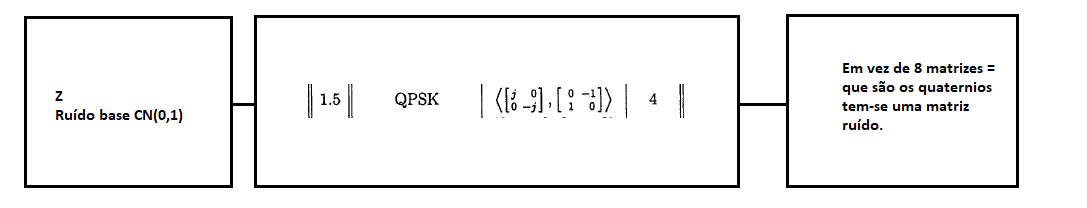

## Outras tentativas de abordagem para a matriz ruido  = generate_noise_codebook

1) Força bruta. Tenta N vezes e escolhe a melhor
2) Otimização pela função custo
3) Otimização por repulsão
